In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [4]:
def load_sensor_logger_android(folder_path, label):
    acc_path = os.path.join(folder_path, 'Accelerometer.csv')
    gyro_path = os.path.join(folder_path, 'Gyroscope.csv')

    # Load accelerometer
    acc = pd.read_csv(acc_path)
    acc = acc.rename(columns={
        'seconds_elapsed': 'timestamp',
        'x': 'acc_x',
        'y': 'acc_y',
        'z': 'acc_z'
    })
    acc = acc[['timestamp', 'acc_x', 'acc_y', 'acc_z']]

    # Load gyroscope
    gyro = pd.read_csv(gyro_path)
    gyro = gyro.rename(columns={
        'seconds_elapsed': 'timestamp',
        'x': 'gyro_x',
        'y': 'gyro_y',
        'z': 'gyro_z'
    })
    gyro = gyro[['timestamp', 'gyro_x', 'gyro_y', 'gyro_z']]

    # Sort both by timestamp
    acc  = acc.sort_values('timestamp').reset_index(drop=True)
    gyro = gyro.sort_values('timestamp').reset_index(drop=True)

    # Merge by nearest timestamp
    merged = pd.merge_asof(acc, gyro, on='timestamp', direction='nearest')

    # Attach label and drop nulls
    merged['label'] = label
    merged = merged.dropna().reset_index(drop=True)

    return merged

In [5]:
# Point this at any ONE of your crash session folders
test_folder = '../data/raw/self_recorded/crash/lan_fall_slowdrop_trouser_1'

df = load_sensor_logger_android(test_folder, label=1)

print(f"Rows:        {len(df)}")
print(f"Duration:    {df['timestamp'].max():.2f} sec")
print(f"Sample rate: {len(df) / df['timestamp'].max():.1f} Hz")
print(f"Columns:     {df.columns.tolist()}")
print(f"Any nulls:   {df.isnull().any().any()}")
print()
print(df.head())

Rows:        253
Duration:    9.67 sec
Sample rate: 26.2 Hz
Columns:     ['timestamp', 'acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z', 'label']
Any nulls:   False

   timestamp     acc_x     acc_y     acc_z    gyro_x    gyro_y    gyro_z  \
0   0.135903  0.597445 -0.860637  0.416546  0.141721 -0.030696  0.057269   
1   0.154915  0.963849 -0.771422  0.643668  0.141721 -0.030696  0.057269   
2   0.192811  0.239547 -2.850395 -0.525530  0.089186  0.072846 -0.283289   
3   0.230714  0.731908 -2.277347 -0.256080 -0.481515 -0.769385  0.560316   
4   0.268620  2.104477  0.150658  0.737510 -0.292146 -2.378404  0.534202   

   label  
0      1  
1      1  
2      1  
3      1  
4      1  


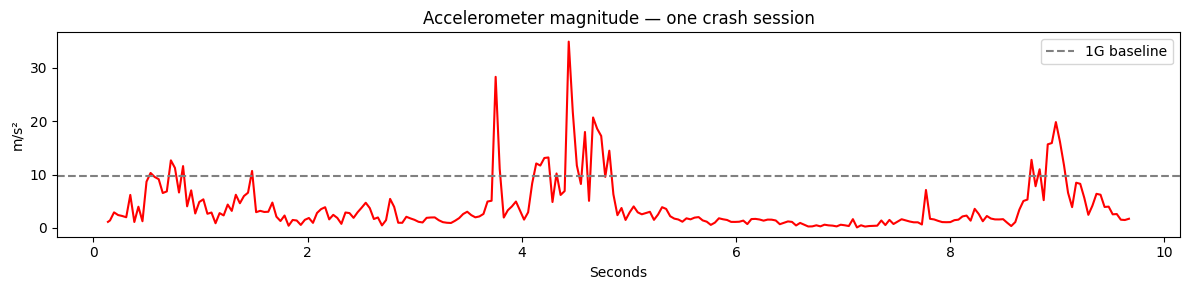

In [6]:
mag = np.sqrt(df['acc_x']**2 + df['acc_y']**2 + df['acc_z']**2)

plt.figure(figsize=(12, 3))
plt.plot(df['timestamp'], mag, color='red')
plt.axhline(9.8, color='gray', linestyle='--', label='1G baseline')
plt.title('Accelerometer magnitude — one crash session')
plt.xlabel('Seconds')
plt.ylabel('m/s²')
plt.legend()
plt.tight_layout()
plt.show()



In [7]:
def load_all_sessions(base_path, label):
    all_frames = []
    
    session_folders = sorted([
        f for f in os.listdir(base_path)
        if os.path.isdir(os.path.join(base_path, f))
    ])
    
    print(f"Found {len(session_folders)} sessions in {base_path}")
    
    for session in session_folders:
        folder = os.path.join(base_path, session)
        try:
            df = load_sensor_logger_android(folder, label)
            all_frames.append(df)
            print(f"  OK  {session}  →  {len(df)} rows  ({df['timestamp'].max():.1f}s)")
        except Exception as e:
            print(f"  FAIL  {session}: {e}")
    
    return pd.concat(all_frames, ignore_index=True)

In [8]:
print("Loading crash sessions...")
crash_data = load_all_sessions(
    '../data/raw/self_recorded/crash', 
    label=1
)

print("\nLoading non-crash sessions...")
non_crash_data = load_all_sessions(
    '../data/raw/self_recorded/non_crash', 
    label=0
)

Loading crash sessions...
Found 41 sessions in ../data/raw/self_recorded/crash
  OK  jump_over_kerb_fall_jacket_1  →  322 rows  (12.2s)
  OK  jump_over_kerb_fall_jacket_2  →  303 rows  (11.5s)
  OK  jump_over_kerb_fall_jacket_3  →  304 rows  (11.7s)
  OK  jump_over_kerb_fall_trouser_1  →  233 rows  (8.9s)
  OK  jump_over_kerb_fall_trouser_2  →  240 rows  (9.3s)
  OK  jump_over_kerb_fall_trouser_3  →  340 rows  (13.0s)
  OK  lan_fall_slowdrop_trouser_1  →  253 rows  (9.7s)
  OK  lan_fall_slowdrop_trouser_2  →  243 rows  (9.2s)
  OK  lan_fall_slowdrop_trouser_3  →  293 rows  (11.1s)
  OK  lan_fall_slowdrop_trouser_4  →  163 rows  (6.3s)
  OK  lan_fall_slowdrop_trouser_5  →  272 rows  (10.4s)
  OK  lean_fall_harddrop_jacket_1  →  306 rows  (11.8s)
  OK  lean_fall_harddrop_jacket_2  →  334 rows  (12.7s)
  OK  lean_fall_harddrop_jacket_3  →  257 rows  (9.8s)
  OK  lean_fall_harddrop_jacket_4  →  330 rows  (12.6s)
  OK  lean_fall_harddrop_jacket_5  →  291 rows  (11.2s)
  OK  lean_fall_harddr

In [9]:
all_data = pd.concat([crash_data, non_crash_data], ignore_index=True)

print(f"\n=== Final dataset summary ===")
print(f"Total rows:      {len(all_data)}")
print(f"Crash rows:      {(all_data['label'] == 1).sum()}")
print(f"Non-crash rows:  {(all_data['label'] == 0).sum()}")

all_data.to_csv('../data/processed/all_data.csv', index=False)
print("\nSaved to data/processed/all_data.csv")


=== Final dataset summary ===
Total rows:      137095
Crash rows:      10795
Non-crash rows:  126300

Saved to data/processed/all_data.csv


In [10]:
print("=== Health check ===")
print(f"Any null values:     {all_data.isnull().any().any()}")
print(f"Any infinite values: {np.isinf(all_data.select_dtypes(include=np.number)).any().any()}")
print(f"Label values:        {all_data['label'].unique()}")
print(f"Columns:             {all_data.columns.tolist()}")

=== Health check ===
Any null values:     False
Any infinite values: False
Label values:        [1 0]
Columns:             ['timestamp', 'acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z', 'label']
